# Minimax: Serial vs Parallel

Paired benchmark: serial and parallel minimax were both run on the same randomly-generated positions at each depth (same row = same board), so the comparison isolates the effect of parallelisation from position-to-position difficulty. See `source/apps/minimax_serial_vs_parallel_test.cpp` (removed after merging into `Minimax.cpp` — see git history) for how the data was generated.

The CSV is already in **wide** format, each row holds both `serial_wall_ms` and `parallel_wall_ms` for the same game/depth, so no pivot is needed before pairing.

This notebook:
1. Loads the data and validates correctness (move agreement, node count parity)
2. Computes per-game speedup ratios
3. Plots serial vs parallel time and speedup vs depth
4. Runs a paired non-parametric test (Wilcoxon) and a bootstrapped CI on the geometric mean speedup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Load and validate

Two correctness checks before trusting any timing number:
- `move_agreement` should be `True` for every row (serial and parallel picked the same board state)
- `node_count_serial` should equal `node_count_parallel` (same tree explored, just split across threads)

In [6]:
df = pd.read_csv("./../results/minimax_serial_vs_parallel_test/minimax_serial_vs_parallel_results.csv")

display(df.head())

,game_id,depth,threads,serial_wall_ms,parallel_wall_ms,move_agreement,node_count_serial,node_count_parallel
0,0,3,8,25.024,4.612,1,2029,2029
1,1,3,8,16.361,3.812,1,1925,1925
2,2,3,8,17.116,4.932,1,2138,2138
3,3,3,8,14.509,4.953,1,2154,2154
4,4,3,8,23.739,8.481,1,3341,3341


In [25]:
print(f"Rows: {len(df)}")
print(f"Threads used: {df['threads'].unique()}")
print()
print("Move agreement check:")
print(df['move_agreement'].value_counts())
print()
print("Node count mismatches:")
mismatched_node_counts = df[df['node_count_serial'] != df['node_count_parallel']]
print(f"{len(mismatched_node_counts)} / {len(df)} rows ")
if len(mismatched_node_counts) > 0:
    print("Mismatched node counts found:")
    display(mismatched_node_counts)

Rows: 75
Threads used: [8]

Move agreement check:
move_agreement
1    75
Name: count, dtype: int64

Node count mismatches:
0 / 75 rows 


## 2. Speedup Ratios

Speedup is defined per-game as `serial_wall_ms / parallel_wall_ms`. Wall-clock times are rightly skewed, so the geometric mean is a more appropriate summery.

In [27]:
df["speedup"] = df["serial_wall_ms"] / df["parallel_wall_ms"]
df["log_speedup"] = np.log(df["speedup"])

geometric_mean_speedup = np.exp(df["log_speedup"].mean())
print(f"Geometric mean speedup: {geometric_mean_speedup:.2f}x")

def geometric_mean(x):
    return np.exp(np.log(x).mean())

ratio_summary = df.groupby("depth")["speedup"].agg(
    geometric_mean=geometric_mean,
)
print("\nGeometric mean speedup by depth:")
display(ratio_summary)

Geometric mean speedup: 2.75x

Geometric mean speedup by depth:


,geometric_mean
depth,
3,3.030686
4,2.667756
5,2.821078
6,2.643388
7,2.590885


## 3. Bootstrapped confidence interval

Calculating a bootstrapped confidence interval on the geometric mean speedup. This gives a range of plausible values for the true geometric mean speedup, based on the observed data. Compared to a point estimate, which doesn't give you an idea of how much this would vary if the benchamrk was repeated.

In [30]:
rng = np.random.default_rng(seed=67)
# Number of bootstrap samples to generate out of the original data. 
n_bootstrap = 10000

log_speedups = df["log_speedup"].to_numpy()
boot_means = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    # Sample with replacement from the log speedups
    sample = rng.choice(log_speedups, size=len(log_speedups), replace=True)
    # Compute the geometric mean of the sample and store it in the boot_means array
    boot_means[i] = np.exp(sample.mean())

# Compute the 95% confidence interval from the bootstrap means
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
print(f"Geometric mean speedup: {geometric_mean_speedup:.2f}x, 95% CI [{ci_low:.2f}x, {ci_high:.2f}x]")

Geometric mean speedup: 2.75x, 95% CI [2.56x, 2.95x]


## 4. Wilcoxon signed-rank test

Test wheather the paired difference (serial time vs parallel time) is consistent and not attributed to chance

In [34]:
stat, p_value = stats.wilcoxon(df["serial_wall_ms"], df["parallel_wall_ms"])
print(f"Wilcoxon signed-rank test: statistic={stat}, p-value={p_value:.2e}")

Wilcoxon signed-rank test: statistic=0.0, p-value=5.28e-14


## 5. Plots

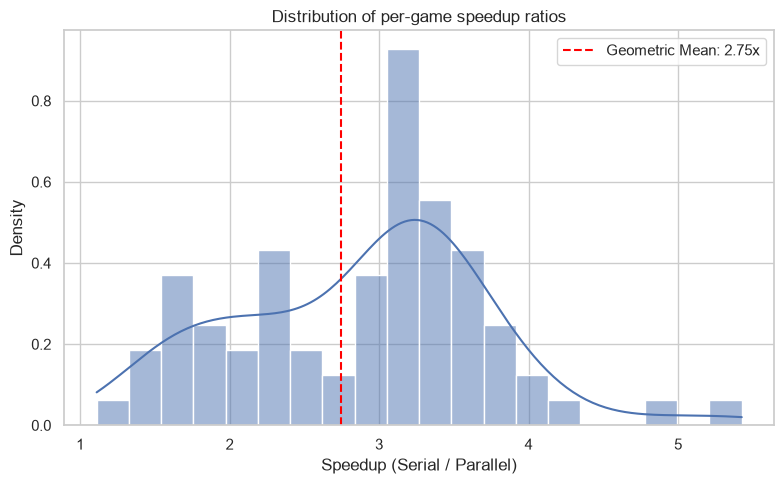

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(df["speedup"], stat="density", bins=20, kde=True, ax=ax)
ax.axvline(geometric_mean_speedup, color='red', linestyle='--', label=f'Geometric Mean: {geometric_mean_speedup:.2f}x')

ax.set_xlabel("Speedup (Serial / Parallel)")

ax.set_title("Distribution of per-game speedup ratios")
ax.legend()

plt.tight_layout()
plt.savefig("./figures/speedup_distribution.png", dpi=150)
plt.show()

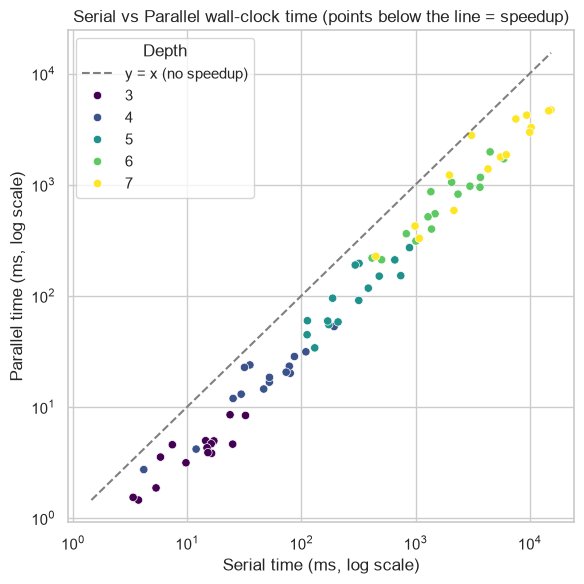

In [40]:
fig, ax = plt.subplots(figsize=(6, 6))

min_val = min(df["serial_wall_ms"].min(), df["parallel_wall_ms"].min())
max_val = max(df["serial_wall_ms"].max(), df["parallel_wall_ms"].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="grey", label="y = x (no speedup)")

sns.scatterplot(data=df, x="serial_wall_ms", y="parallel_wall_ms", hue="depth", palette="viridis", ax=ax)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Serial time (ms, log scale)")
ax.set_ylabel("Parallel time (ms, log scale)")

ax.set_title("Serial vs Parallel wall-clock time (points below the line = speedup)")

ax.legend(title="Depth")

plt.tight_layout()
plt.savefig("figures/serial_vs_parallel_scatter.png", dpi=150)
plt.show()

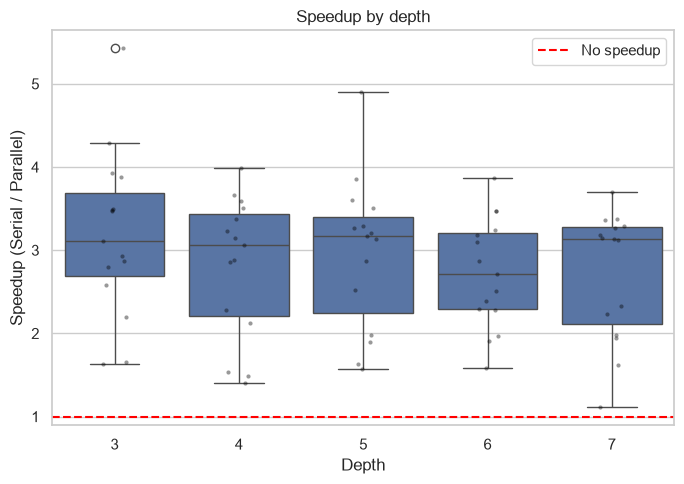

In [43]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(data=df, x="depth", y="speedup", ax=ax)
sns.stripplot(data=df, x="depth", y="speedup", color="black", alpha=0.4, size=3, ax=ax)

ax.axhline(1.0, color="red", linestyle="--", label="No speedup")

ax.set_xlabel("Depth")
ax.set_ylabel("Speedup (Serial / Parallel)")

ax.set_title("Speedup by depth")

ax.legend()

plt.tight_layout()
plt.savefig("figures/speedup_by_depth.png", dpi=150)
plt.show()

## TODO

1. Summary paragraph: 
   - Geometric mean speedup and CI
   - Wilcoxon test result